# Distribution Planning Benchmark

This notebook imports saved distribution-planning runs from `results/distribution`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_distribution_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'distribution'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 30 saved runs from /home/adonis/Internship/mfc/results/distribution


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Higher is better because the reward is the negative mismatch and movement cost.

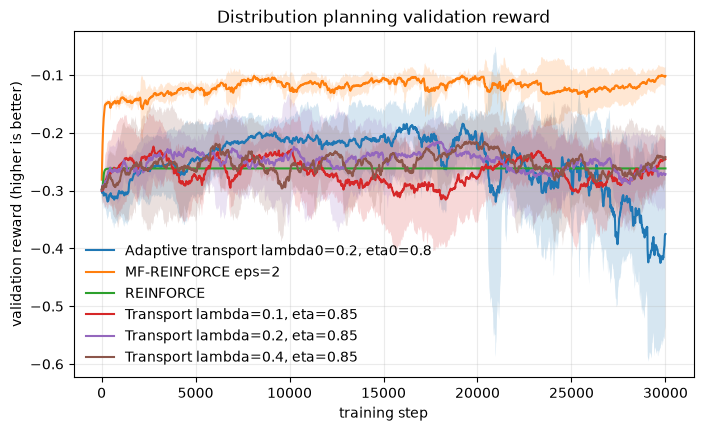

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=5, flow='exact', ax=ax)
    ax.set_title('Distribution planning validation reward')
    plt.show()

## Initial, Target, and Learned Distributions

Bar charts comparing the uniform initial law, the fixed target law, and the terminal population distribution induced by the best saved policy for each configuration.

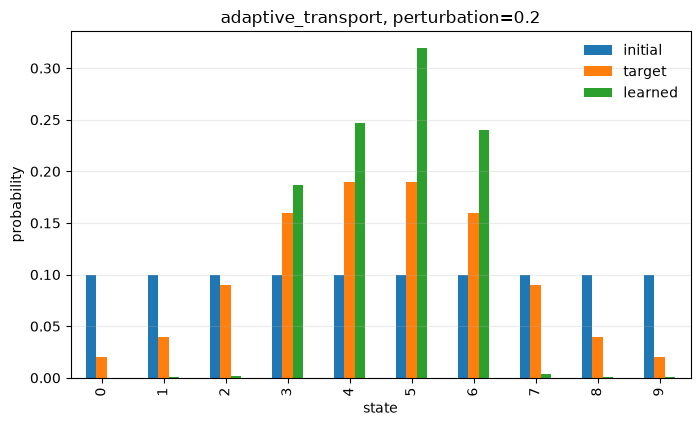

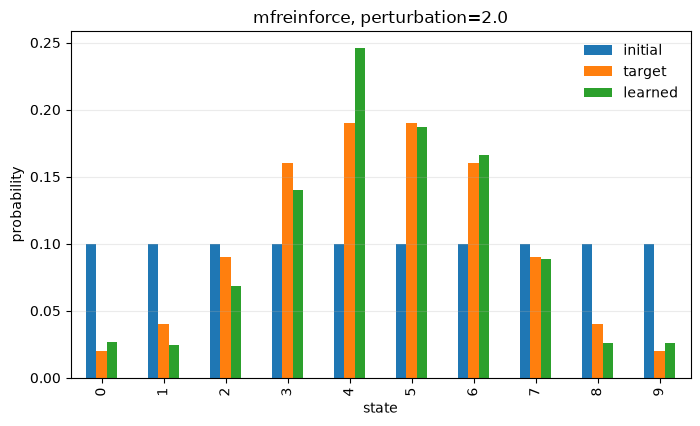

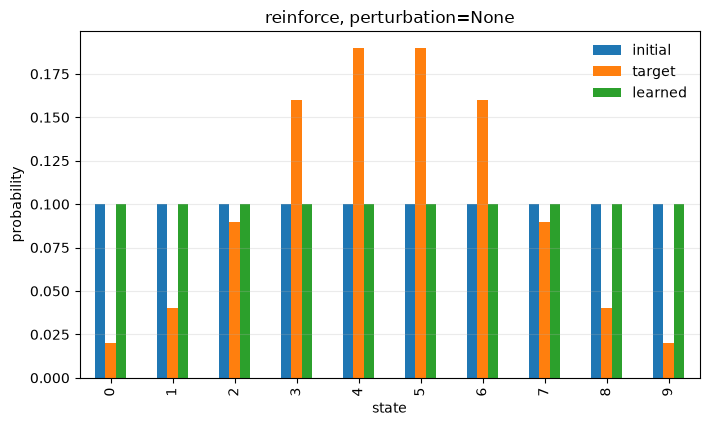

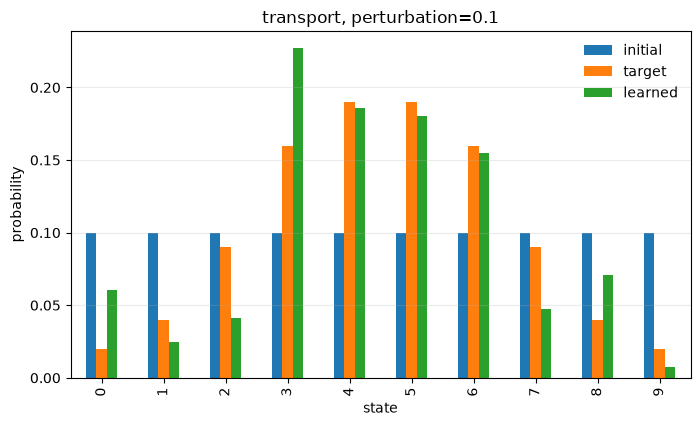

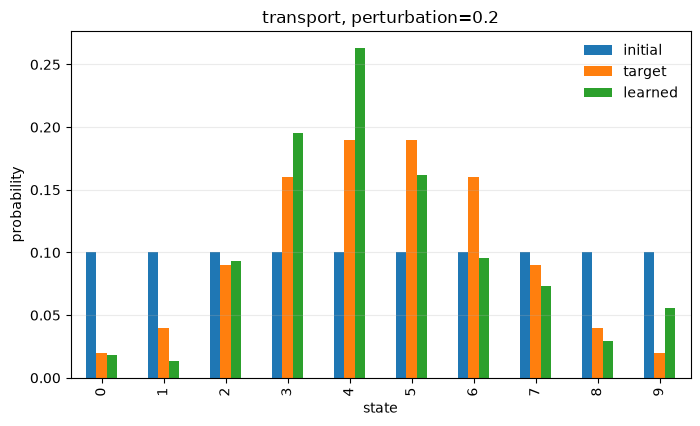

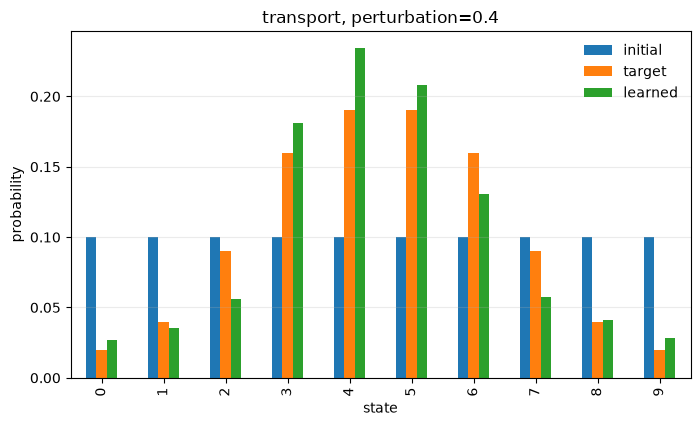

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_distribution_comparison(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Learned Flow Over Time

State-probability trajectories under selected learned policies. These curves show whether the policy moves mass coherently toward the target or oscillates around it.

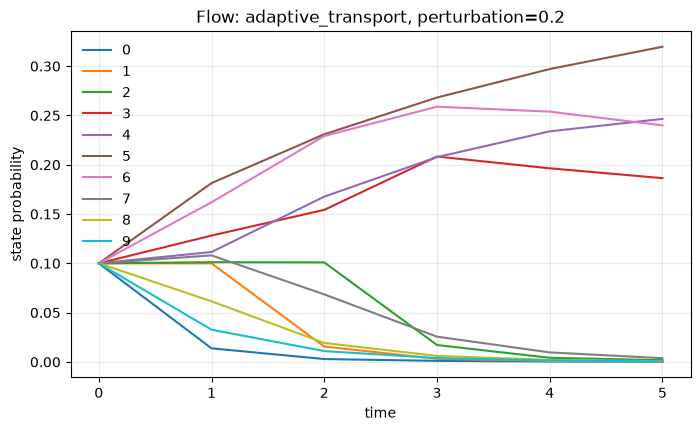

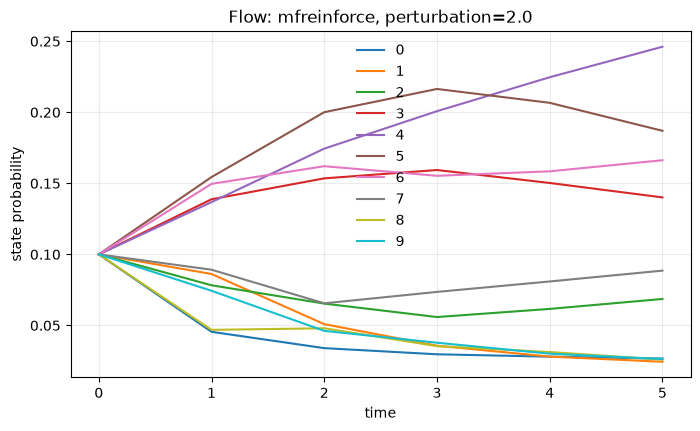

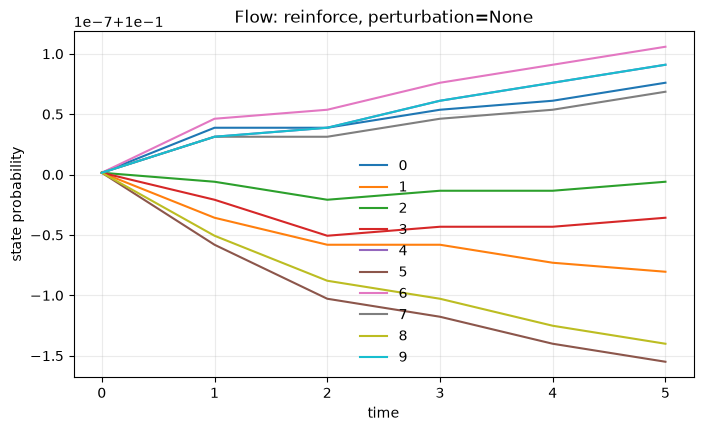

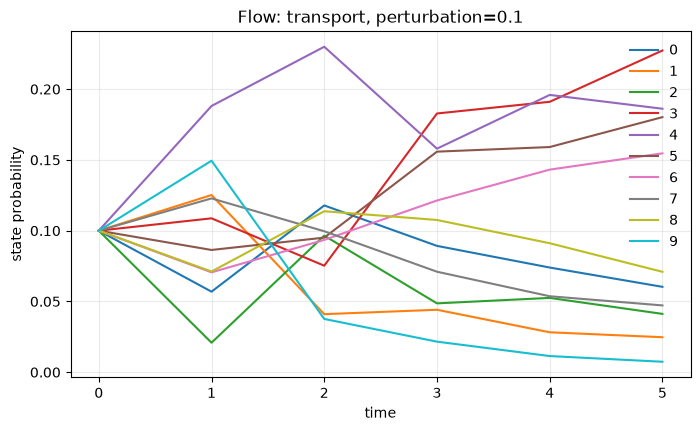

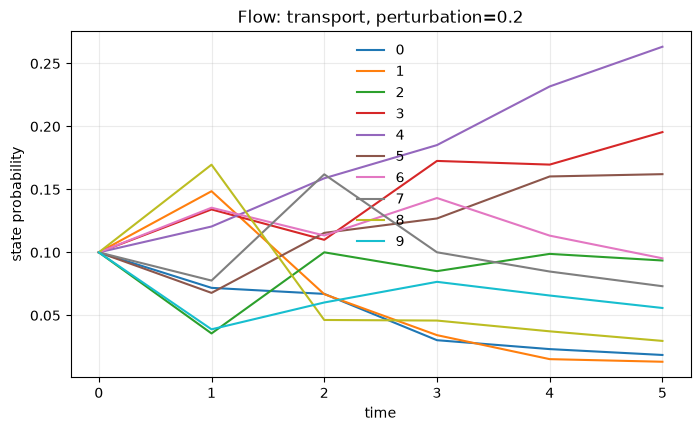

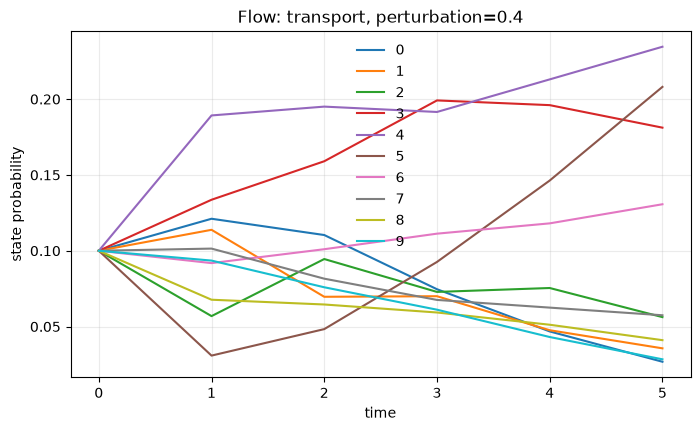

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"Flow: {meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the sampled perturbed law and the unperturbed law is bounded by `lambda`.

In [5]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,eta,max_tv_upper_bound,satisfies_lambda_bound
0,distribution,"Transport lambda=0.1, eta=0.85",exact,5,0,0.1,0.85,0.099562,True
1,distribution,"Transport lambda=0.1, eta=0.85",exact,5,1,0.1,0.85,0.098644,True
2,distribution,"Transport lambda=0.1, eta=0.85",exact,5,2,0.1,0.85,0.099261,True
3,distribution,"Transport lambda=0.1, eta=0.85",exact,5,3,0.1,0.85,0.099369,True
4,distribution,"Transport lambda=0.1, eta=0.85",exact,5,4,0.1,0.85,0.099914,True
5,distribution,"Transport lambda=0.2, eta=0.85",exact,5,0,0.2,0.85,0.197926,True
6,distribution,"Transport lambda=0.2, eta=0.85",exact,5,1,0.2,0.85,0.198944,True
7,distribution,"Transport lambda=0.2, eta=0.85",exact,5,2,0.2,0.85,0.197943,True
8,distribution,"Transport lambda=0.2, eta=0.85",exact,5,3,0.2,0.85,0.197369,True
9,distribution,"Transport lambda=0.2, eta=0.85",exact,5,4,0.2,0.85,0.199863,True


## Objective and Runtime Tables

Final validation rewards, estimated simulator budgets, and runtime summaries.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,eta,seed,validation_reward
0,distribution,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.937910,0,-0.203592
1,distribution,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.937957,1,-0.201068
2,distribution,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.961385,2,-0.455880
3,distribution,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.955283,3,-0.533751
4,distribution,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,0.911771,4,-0.480705
5,distribution,MF-REINFORCE eps=2,exact,5,2.000000,0,-0.090342
6,distribution,MF-REINFORCE eps=2,exact,5,2.000000,1,-0.128468
7,distribution,MF-REINFORCE eps=2,exact,5,2.000000,2,-0.088191
8,distribution,MF-REINFORCE eps=2,exact,5,2.000000,3,-0.101692
9,distribution,MF-REINFORCE eps=2,exact,5,2.000000,4,-0.099611


,env,algorithm,perturbation,eta,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,distribution,adaptive_transport,0.2,NaN,5,exact,9.435113,2.326027,6391.122438,360.443659,95.471970,0.550885,6496.249276,360.329564,0.213037,0.216542,0.031824,2797.2,5
1,distribution,mfreinforce,2.0,2.00,5,exact,8.264093,0.873757,6517.157343,56.424171,96.499070,0.461857,6622.092844,56.192689,0.217239,0.220736,0.032166,2800.0,5
2,distribution,reinforce,NaN,NaN,5,exact,8.919156,2.141464,160.810027,1.363672,93.572165,1.236602,263.402407,2.632537,0.005360,0.008780,0.031191,2800.0,5
3,distribution,transport,0.1,0.85,5,exact,8.826240,1.156194,6696.383596,189.557607,96.446581,0.864123,6801.832956,189.322766,0.223213,0.226728,0.032149,2800.0,5
4,distribution,transport,0.2,0.85,5,exact,7.489385,0.284186,6603.291303,79.584393,96.676520,1.224218,6707.625975,79.051462,0.220110,0.223588,0.032226,2800.0,5
5,distribution,transport,0.4,0.85,5,exact,8.262849,1.964133,6392.078451,193.735442,96.368734,0.499723,6496.883793,194.424259,0.213069,0.216563,0.032123,2800.0,5
